<a href="https://colab.research.google.com/github/Vino8801/Market-campaign-dataset-analysis/blob/main/FINAL_Programming_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
Qeqaqqqwwqqwwweeeeserrrdrrrtttyyyuuuukiiokoopppaaasssdddddffffggbghhjjkkll'
import pandas as pd

data = pd.read_csv('/content/drive/MyDrive/Marketing Campaign data.csv')
metadata = pd.DataFrame()
metadata = pd.DataFrame(columns=['Descriptions', 'Mean'])
Descriptions ={
    'CUST_ID' : 'Customer ID',
    'CUST_GENDER': 'Gender of the customer',
    'AGE' : 'Age of the customer',
    'CUST_MARITAL_STATUS' : 'Marital status of the customer',
    'COUNTRY_NAME' : 'Country of the customer',
    'CUST_INCOME_LEVEL' : 'Income level of the customer',
    'EDUCATION' : 'Education level of the customer',
    'OCCUPATION' : 'Occupation of the customer',
    'HOUSEHOLD_SIZE' : 'Household size',
    'YRS_RESIDENCE' : 'Years of residence',
    'AFFINITY_CARD' : 'Affinity card usage',
    'BULK_PACK_DISKETTES' : 'Bulk pack diskettes purchase',
    'FLAT_PANEL_MONITOR' : 'Flat panel monitor purchase',
    'HOME_THEATER_PACKAGE' : 'Home theater package purchase',
    'BOOKKEEPING_APPLICATION' : 'Bookkeeping application purchase',
    'PRINTER_SUPPLIES' : 'Printer supplies purchase',
    'Y_BOX_GAMES' : 'Y-box games purchase',
    'OS_DOC_SET_KANJI' : 'Opearting system document set (kanji) purchase',
    'COMMENTS' : 'Additional comments'
}
metadata['Data Type'] = data.dtypes
metadata['Unique Values'] = data.nunique()
metadata['Count'] = data.count()

for column in data.columns:
  metadata.loc[column,'Descriptions'] = Descriptions.get(column,'')

  if pd.api.types.is_numeric_dtype(data[column]):
    metadata.loc[column, 'Min'] = data[column].min()
    metadata.loc[column, 'Max'] = data[column].max()
    metadata.loc[column, 'Mean'] = data[column].mean()
    metadata.loc[column, 'Std Deviation'] = data[column].std()


metadata

,Descriptions,Mean,Data Type,Unique Values,Count,Min,Max,Std Deviation
CUST_ID,Customer ID,102250.5,int64,1500,1500,101501.0,103000.0,433.157015
CUST_GENDER,Gender of the customer,NaN,object,2,1500,NaN,NaN,NaN
AGE,Age of the customer,38.892,int64,66,1500,17.0,90.0,13.636384
CUST_MARITAL_STATUS,Marital status of the customer,NaN,object,7,1500,NaN,NaN,NaN
COUNTRY_NAME,Country of the customer,NaN,object,19,1500,NaN,NaN,NaN
CUST_INCOME_LEVEL,Income level of the customer,NaN,object,12,1500,NaN,NaN,NaN
EDUCATION,Education level of the customer,NaN,object,16,1500,NaN,NaN,NaN
OCCUPATION,Occupation of the customer,NaN,object,15,1500,NaN,NaN,NaN
HOUSEHOLD_SIZE,Household size,NaN,object,6,1500,NaN,NaN,NaN
YRS_RESIDENCE,Years of residence,4.088667,int64,15,1500,0.0,14.0,1.920919


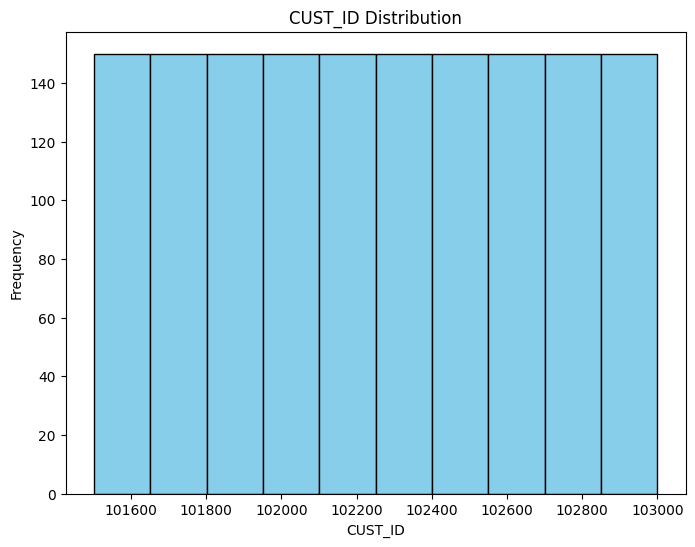

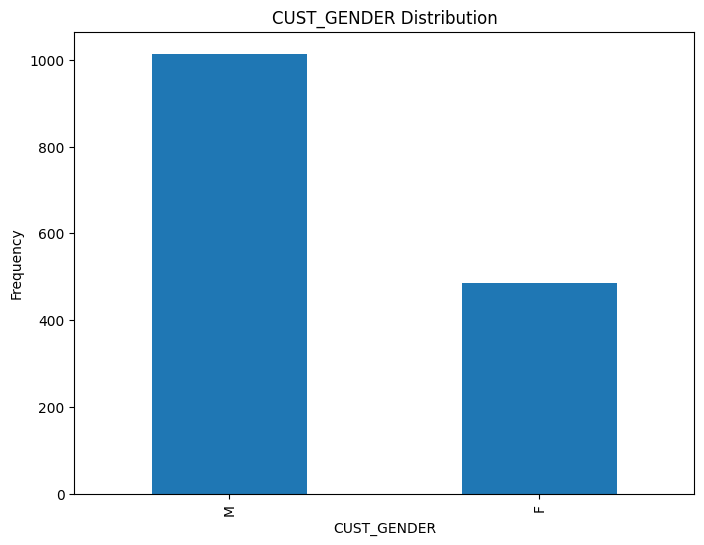

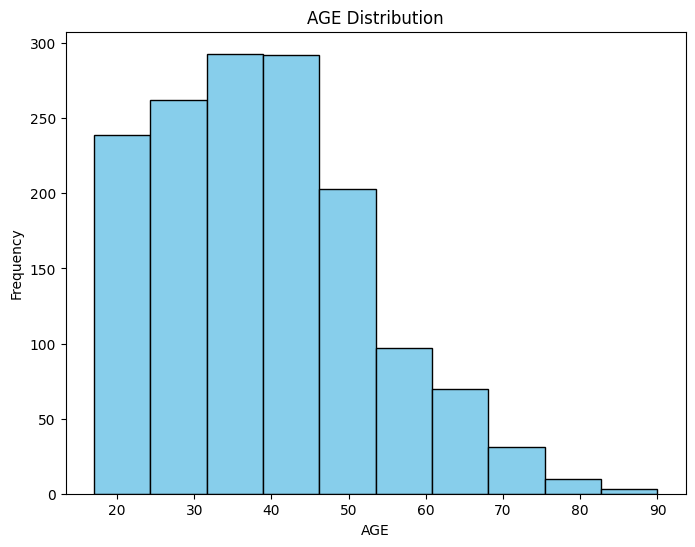

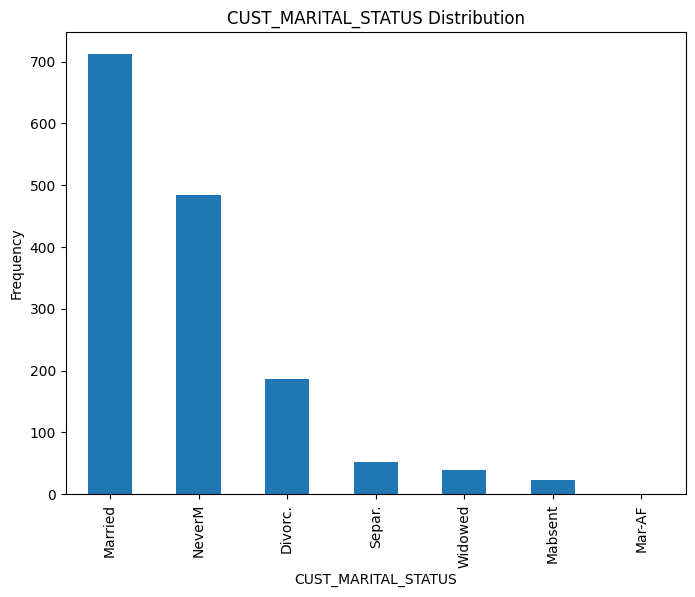

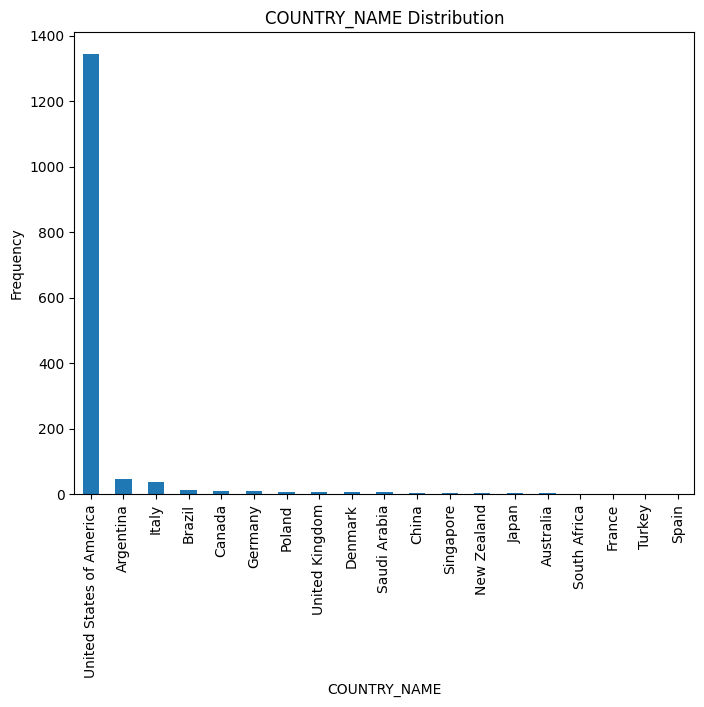

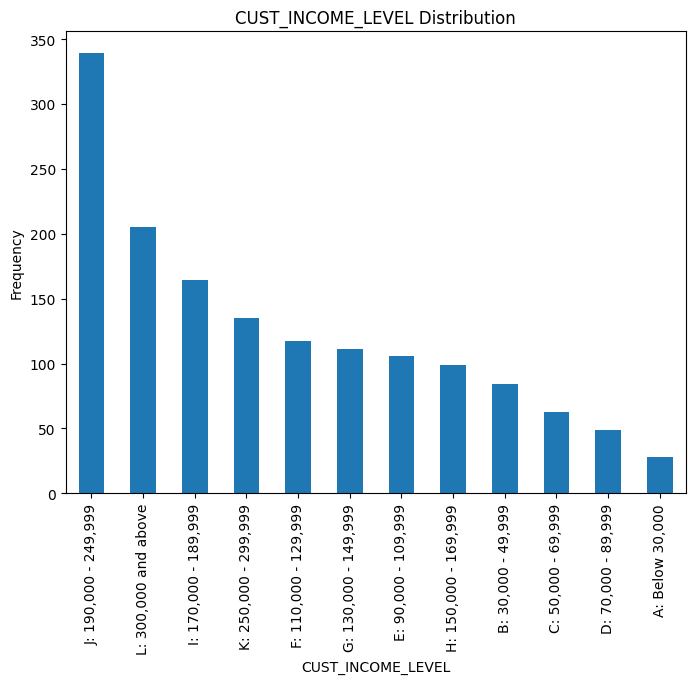

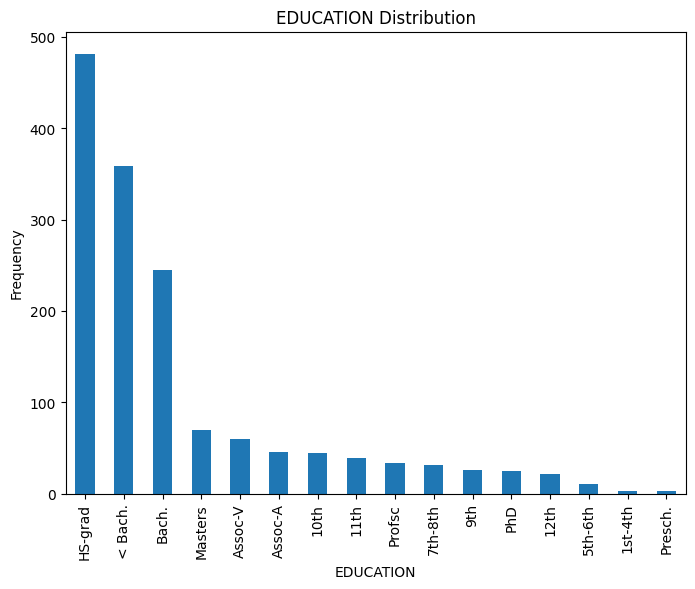

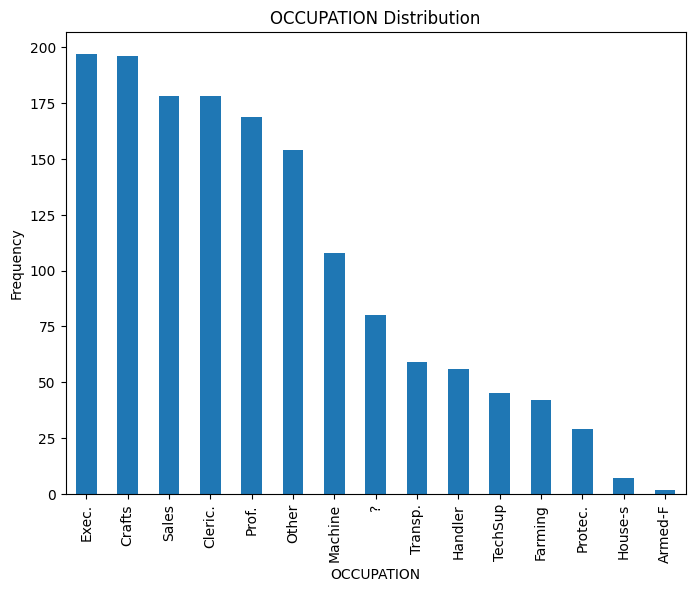

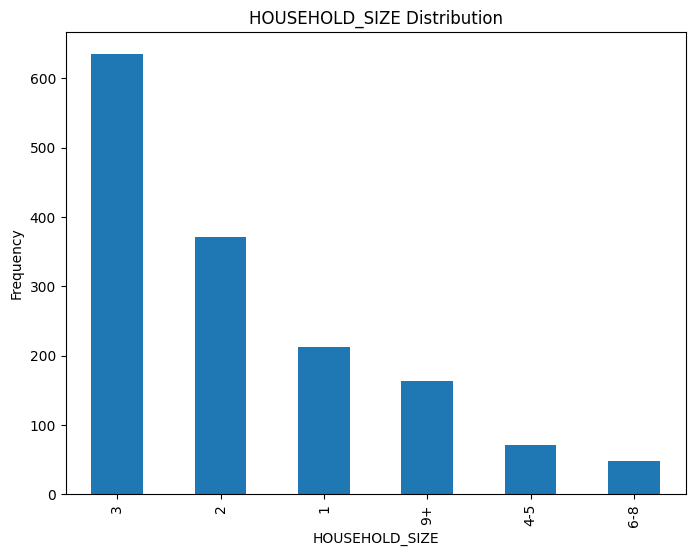

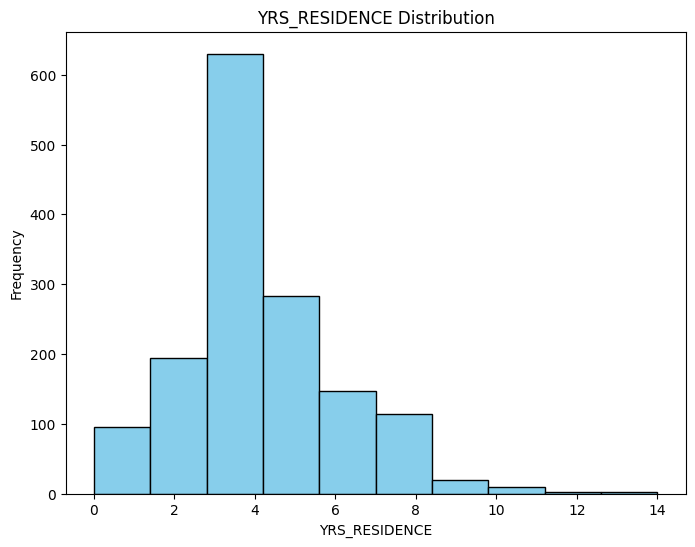

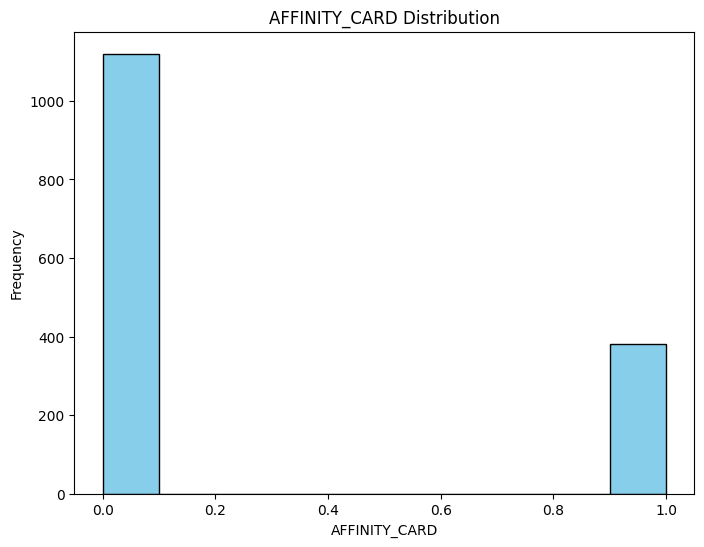

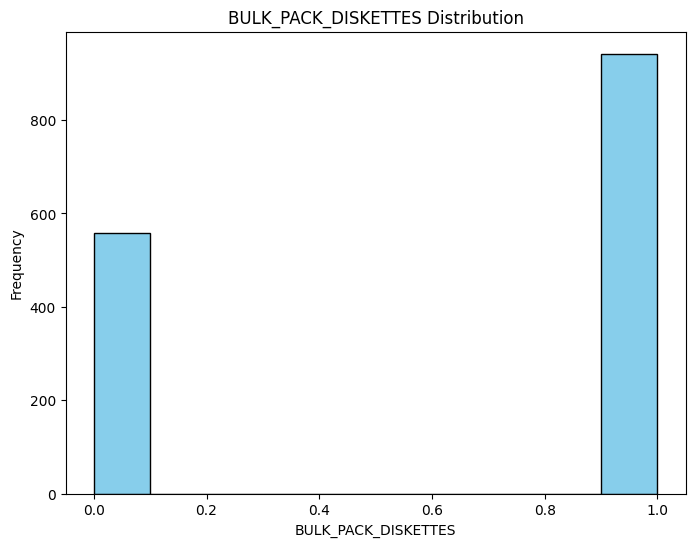

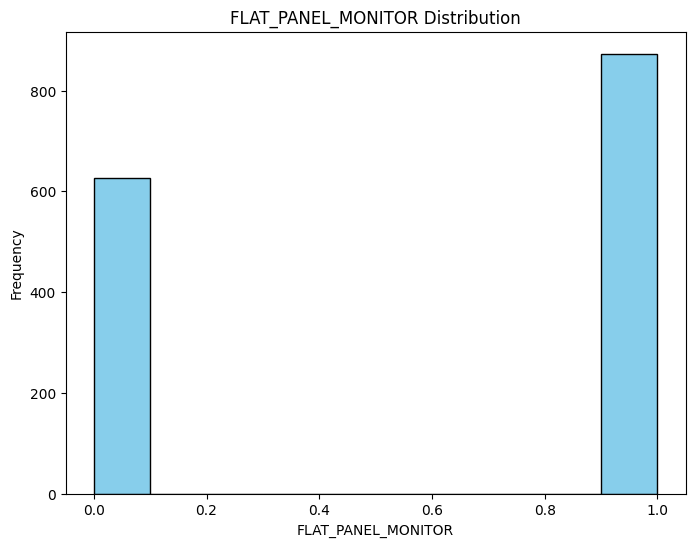

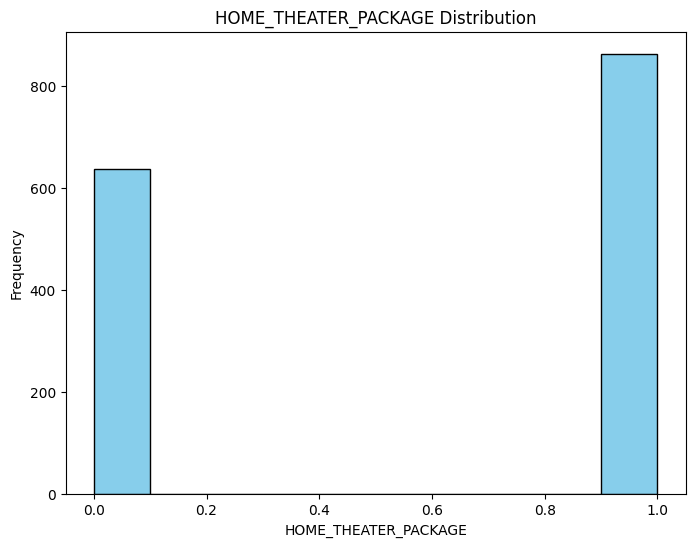

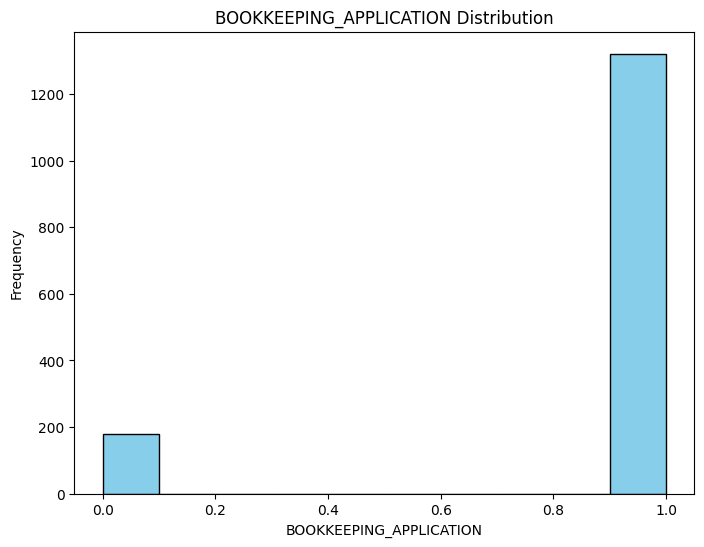

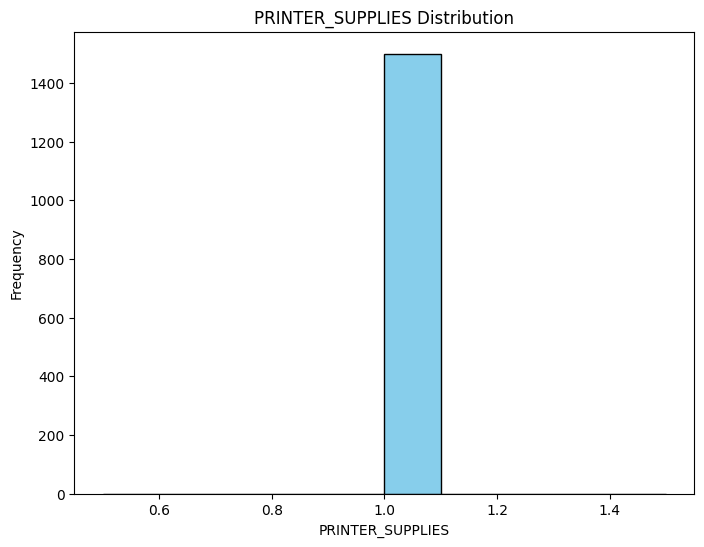

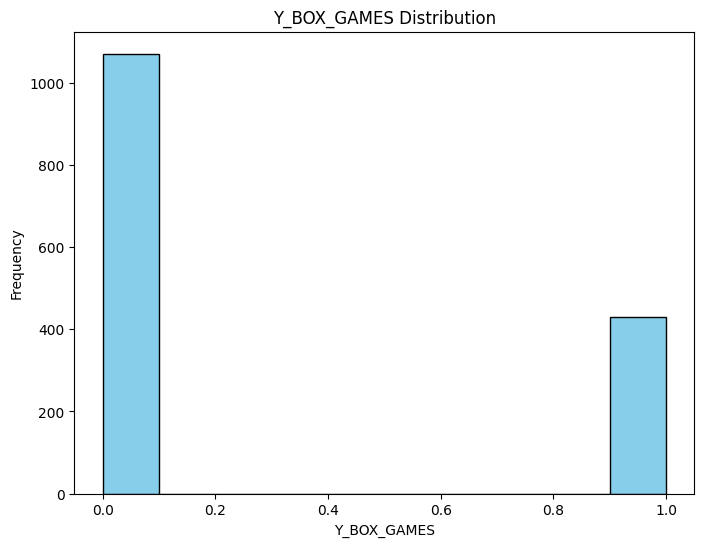

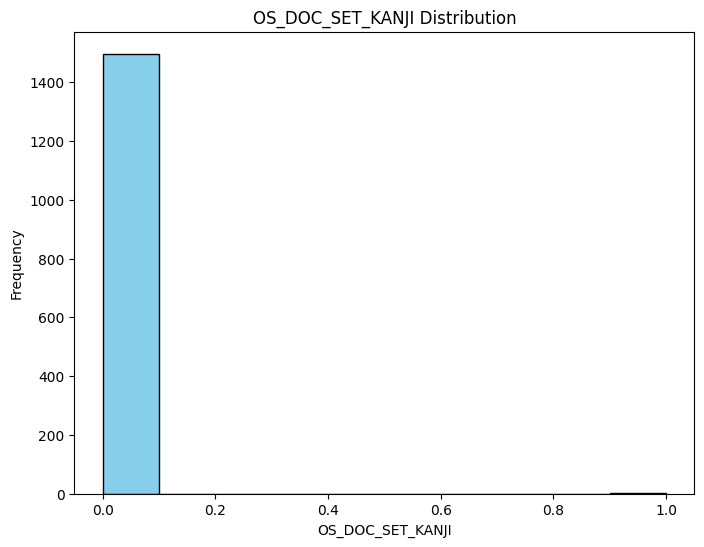

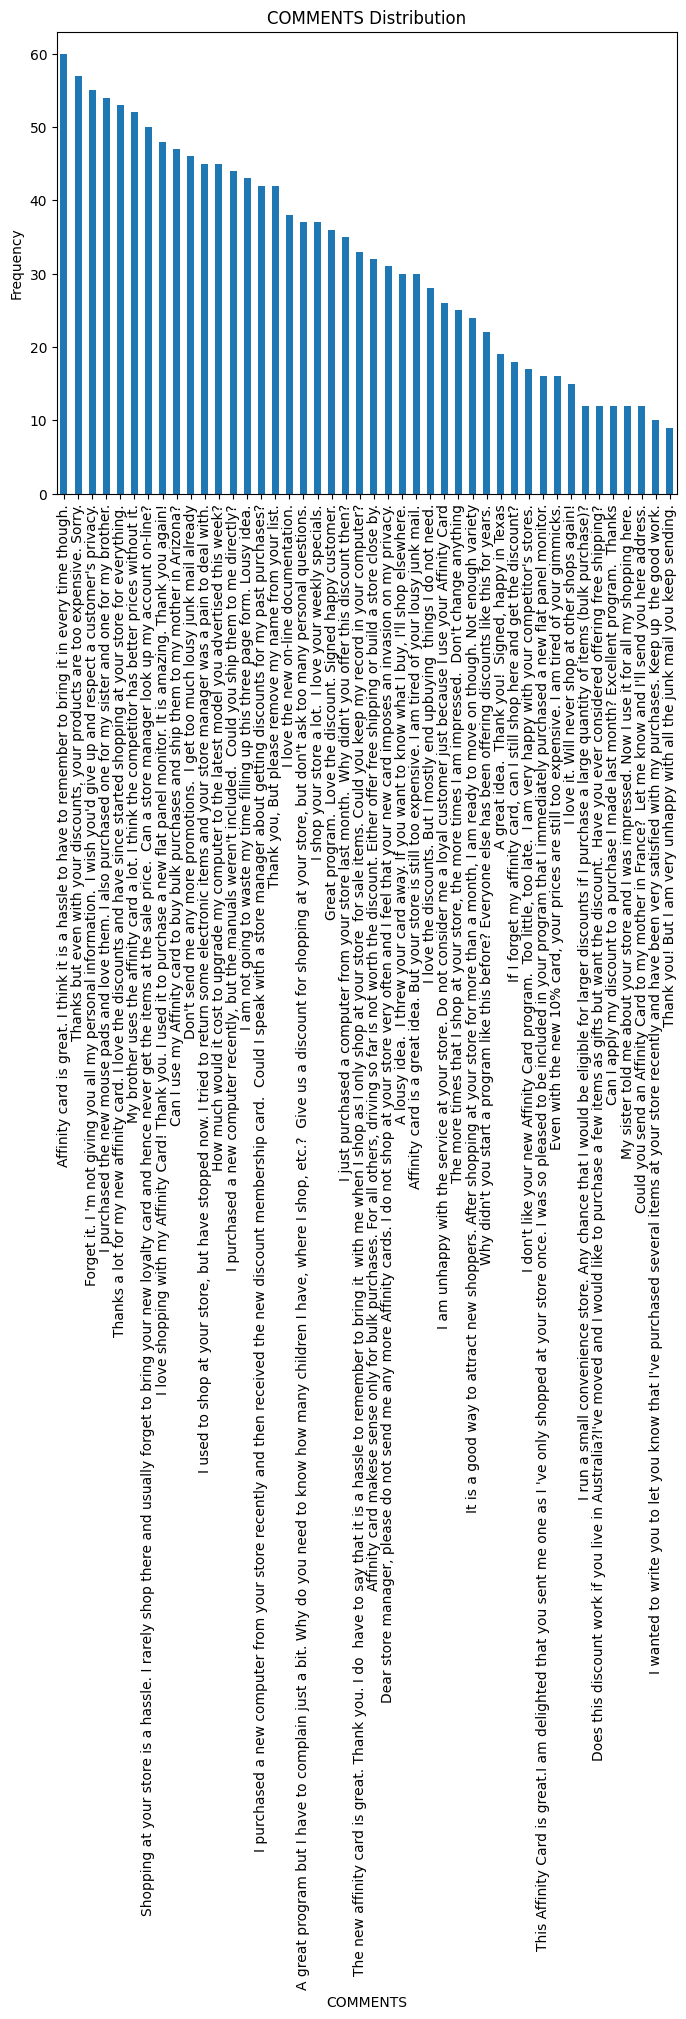

In [ ]:
import matplotlib.pyplot as plt
#Define a function to generate metadata for each column
def generate_metadata(column):
    metadata = {}
    metadata['Attribute Name'] = column.name
    metadata['Description'] = "Description of the attribute"  # Add descriptions as per your knowledge

    if column.dtype == 'object':  # Check if the column is nominal
        metadata['Mode'] = column.mode()[0]
        plt.figure(figsize=(8, 6))
        column.value_counts().plot(kind='bar')
        plt.title(f'{column.name} Distribution')
        plt.xlabel(column.name)
        plt.ylabel('Frequency')
        plt.show()
    else:  # Numeric data
        try:
            column_numeric = pd.to_numeric(column, errors='coerce')  # Convert to numeric, coerce errors to NaN
            column_numeric = column_numeric.dropna()  # Drop NaN values
            metadata['Maximum'] = column_numeric.max()
            metadata['Minimum'] = column_numeric.min()
            metadata['Mean'] = column_numeric.mean()
            metadata['Std. Deviation'] = column_numeric.std()

            plt.figure(figsize=(8, 6))
            plt.hist(column_numeric, bins=10, color='skyblue', edgecolor='black')
            plt.title(f'{column.name} Distribution')
            plt.xlabel(column.name)
            plt.ylabel('Frequency')
            plt.show()
        except ValueError:
            print(f"Warning: {column.name} contains non-numeric values and will be excluded from numeric metadata.")

    return metadata

# Generate metadata for each column
metadata_list = []
for column in data.columns:
    metadata_list.append(generate_metadata(data[column]))

# Convert metadata list to DataFrame for easy viewing
metadata_df = pd.DataFrame(metadata_list)

In [ ]:
# Define the list of column names
column_names = ['CUST_GENDER', 'CUST_MARITAL_STATUS', 'COUNTRY_NAME', 'CUST_INCOME_LEVEL', 'EDUCATION', 'OCCUPATION', 'AFFINITY_CARD', 'BULK_PACK_DISKETTES', 'FLAT_PANEL_MONITOR', 'HOME_THEATER_PACKAGE', 'BOOKKEEPING_APPLICATION', 'PRINTER_SUPPLIES', 'Y_BOX_GAMES', 'OS_DOC_SET_KANJI']

# Calculate mode for each nominal attribute
mode_values = data[column_names].mode().iloc[0]
mode_values.index.name = 'Attribute'
mode_values.name = 'Mode'

print("Mode for each nominal attribute:")
print(mode_values)


Mode for each nominal attribute:
Attribute
CUST_GENDER                                       M
CUST_MARITAL_STATUS                         Married
COUNTRY_NAME               United States of America
CUST_INCOME_LEVEL              J: 190,000 - 249,999
EDUCATION                                   HS-grad
OCCUPATION                                    Exec.
AFFINITY_CARD                                     0
BULK_PACK_DISKETTES                               1
FLAT_PANEL_MONITOR                                1
HOME_THEATER_PACKAGE                              1
BOOKKEEPING_APPLICATION                           1
PRINTER_SUPPLIES                                  1
Y_BOX_GAMES                                       0
OS_DOC_SET_KANJI                                  0
Name: Mode, dtype: object


In [ ]:
# Define expected patterns or ranges for each attribute (if applicable)
expected_patterns_or_ranges = {
    'CUST_ID': None,
    'AGE': (17, 90),
    'GENDER': ['Male', 'Female'],
    'INCOME': (0, None),
    'EDUCATION': ['High School', 'Bachelor', 'Master', 'PhD','Masters', 'Bach.', 'HS-grad','< Bach.', 'Profsc', '11th', '< Bach.', '5th-6th','Assoc-A', 'Assoc-V', '7th-8th', '7th-8th', '9th','10th', '1st-4th', '10th', '12th','Presch.'],
    'OCCUPATION': ['Armed-F', 'Cleric.', 'Crafts', 'Exec.', 'Farming', 'Handler', 'House-s', 'Machine', 'Other', 'Prof.', 'Protec.', 'Sales', 'TechSup', 'Transp.'],
    'HOUSEHOLD_SIZE': ('1', '2', '3', '4-5', '6-8', '9+'),
    'YRS_RESIDENCE': list(range(15)),
    'AFFINITY_CARD': [0, 1],
    'BULK_PACK_DISKETTES': [0, 1],
    'FLAT_PANEL_MONITOR': [0, 1],
    'HOME_THEATER_PACKAGE': [0, 1],
    'BOOKKEEPING_APPLICATION': [0, 1],
    'PRINTER_SUPPLIES': [1],
    'Y_BOX_GAMES': [0, 1],
    'OS_DOC_SET_KANJI': [0, 1],
    'COMMENTS': None
}

# Initialize dictionaries to store missing and error data counts
missing_data_counts = {}
error_data_counts = {}
error_data_types = {}

# Iterate over each attribute to count missing and error data
for attribute in data.columns:
    # Count missing data types: null, blank, unknown
    missing_data_count = data[attribute].isnull().sum() + data[attribute].eq('').sum()
    missing_data_counts[attribute] = missing_data_count

    # Initialize error data count and types for the attribute
    error_data_count = 0
    error_data_types[attribute] = []

    if attribute in expected_patterns_or_ranges:
        expected_values = expected_patterns_or_ranges[attribute]
        if expected_values is not None:
            if isinstance(expected_values, tuple) and len(expected_values) == 2:  # Check for numerical range
                min_val, max_val = expected_values
                for value in data[attribute]:
                    if not (min_val <= value <= max_val):
                        error_data_count += 1
                        error_data_types[attribute].append(value)
            elif isinstance(expected_values, list):  # Check for categorical values
                for value in data[attribute]:
                    if value not in expected_values:
                        error_data_count += 1
                        error_data_types[attribute].append(value)

    # Store error data count for the attribute
    error_data_counts[attribute] = error_data_count

# Print counts for missing and error data in each attribute
for attribute in data.columns:
    print(f"Attribute: {attribute}")
    print(f"Missing Data Count: {missing_data_counts.get(attribute, 0)}")
    print(f"Error Data Count: {error_data_counts.get(attribute, 0)}")
    print(f"Error Data Types: {error_data_types.get(attribute, [])}")
    print()

Attribute: CUST_ID
Missing Data Count: 0
Error Data Count: 0
Error Data Types: []

Attribute: CUST_GENDER
Missing Data Count: 0
Error Data Count: 0
Error Data Types: []

Attribute: AGE
Missing Data Count: 0
Error Data Count: 0
Error Data Types: []

Attribute: CUST_MARITAL_STATUS
Missing Data Count: 0
Error Data Count: 0
Error Data Types: []

Attribute: COUNTRY_NAME
Missing Data Count: 0
Error Data Count: 0
Error Data Types: []

Attribute: CUST_INCOME_LEVEL
Missing Data Count: 0
Error Data Count: 0
Error Data Types: []

Attribute: EDUCATION
Missing Data Count: 0
Error Data Count: 0
Error Data Types: []

Attribute: OCCUPATION
Missing Data Count: 0
Error Data Count: 80
Error Data Types: ['?', '?', '?', '?', '?', '?', '?', '?', '?', '?', '?', '?', '?', '?', '?', '?', '?', '?', '?', '?', '?', '?', '?', '?', '?', '?', '?', '?', '?', '?', '?', '?', '?', '?', '?', '?', '?', '?', '?', '?', '?', '?', '?', '?', '?', '?', '?', '?', '?', '?', '?', '?', '?', '?', '?', '?', '?', '?', '?', '?', '?', '

In [ ]:
# Remove non-numeric columns and the target variable (AFFINITY_CARD) from the dataset
numeric_data = data.select_dtypes(include=['int', 'float'])

# Calculate correlation between each attribute and the target variable
correlation = numeric_data.corrwith(data['AFFINITY_CARD']).drop('AFFINITY_CARD', errors='ignore')

# Identify variables with zero correlation (or close to zero)
zero_influence_variables = correlation[correlation.abs() < 0.05].index.tolist()

# Remove variables with zero influence from the dataset
reduced_data = data.drop(columns=zero_influence_variables)

# Print the reduced dataset
print("Zero influence variable")
print(zero_influence_variables)

Zero influence variable
['CUST_ID', 'BULK_PACK_DISKETTES', 'FLAT_PANEL_MONITOR', 'OS_DOC_SET_KANJI']


In [ ]:
import pandas as pd

# Assuming 'AFFINITY_CARD' is the target variable
target_variable = 'AFFINITY_CARD'

# Function to identify variables with zero influence on the target variable
def identify_zero_influence_variables(data, target_variable):
    influence_threshold = 0.05  # Adjust threshold as needed
    zero_influence_variables = []
    for column in data.columns:
        if column != target_variable:
            if pd.api.types.is_numeric_dtype(data[column]):  # Check if the column is numeric
                correlation = data[[column, target_variable]].corr().iloc[0, 1]
                if abs(correlation) < influence_threshold:
                    zero_influence_variables.append(column)
            else:
                print(f"Skipping non-numeric column '{column}'")
    return zero_influence_variables

# Function to reduce variables based on zero influence and COMMENTS
def reduce_variables(data, target_variable):
    # Identify variables with zero influence on the target variable
    zero_influence_vars = identify_zero_influence_variables(data, target_variable)

    # Remove 'COMMENTS' variable regardless of its correlation with the target variable
    if 'COMMENTS' in data.columns:
        zero_influence_vars.append('COMMENTS')

    # Drop identified variables
    reduced_data = data.drop(zero_influence_vars, axis=1)
    print("Zero-influeced removed columns:",zero_influence_vars)

    return reduced_data

# Reduce variables based on the defined criteria
reduced_df = reduce_variables(data, target_variable)

# Print the reduced DataFrame
reduced_df

Skipping non-numeric column 'CUST_GENDER'
Skipping non-numeric column 'CUST_MARITAL_STATUS'
Skipping non-numeric column 'COUNTRY_NAME'
Skipping non-numeric column 'CUST_INCOME_LEVEL'
Skipping non-numeric column 'EDUCATION'
Skipping non-numeric column 'OCCUPATION'
Skipping non-numeric column 'HOUSEHOLD_SIZE'
Skipping non-numeric column 'COMMENTS'
Zero-influeced removed columns: ['CUST_ID', 'BULK_PACK_DISKETTES', 'FLAT_PANEL_MONITOR', 'OS_DOC_SET_KANJI', 'COMMENTS']


,CUST_GENDER,AGE,CUST_MARITAL_STATUS,COUNTRY_NAME,CUST_INCOME_LEVEL,EDUCATION,OCCUPATION,HOUSEHOLD_SIZE,YRS_RESIDENCE,AFFINITY_CARD,HOME_THEATER_PACKAGE,BOOKKEEPING_APPLICATION,PRINTER_SUPPLIES,Y_BOX_GAMES
0,F,41,NeverM,United States of America,"J: 190,000 - 249,999",Masters,Prof.,2,4,0,1,1,1,0
1,M,27,NeverM,United States of America,"I: 170,000 - 189,999",Bach.,Sales,2,3,0,0,1,1,1
2,F,20,NeverM,United States of America,"H: 150,000 - 169,999",HS-grad,Cleric.,2,2,0,0,1,1,1
3,M,45,Married,United States of America,"B: 30,000 - 49,999",Bach.,Exec.,3,5,1,1,1,1,0
4,M,34,NeverM,United States of America,"K: 250,000 - 299,999",Masters,Sales,9+,5,1,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1495,M,17,NeverM,United States of America,"C: 50,000 - 69,999",10th,Other,1,1,0,0,0,1,1
1496,M,41,Married,Spain,"L: 300,000 and above",Bach.,Exec.,3,4,0,1,1,1,0
1497,M,53,Married,United States of America,"J: 190,000 - 249,999",HS-grad,Exec.,3,8,1,1,1,1,0
1498,M,55,Married,United States of America,"C: 50,000 - 69,999",HS-grad,Cleric.,3,7,1,1,1,1,0


In [ ]:
# Identify rows with '?' in the 'occupation' column
rows_with_question_mark = reduced_df[reduced_df['OCCUPATION'] == '?']

# Print the rows with '?' in the 'occupation' column
print("Rows with '?' in the 'OCCUPATION' column:")
print(rows_with_question_mark)

# Remove rows with '?' in the 'occupoccation' column
cleaned_df = reduced_df[reduced_df['OCCUPATION'] != '?']

# Print the number of rows after handling '?' values
print("Number of rows after handling '?' values:", len(cleaned_df))

Rows with '?' in the 'OCCUPATION' column:
     CUST_GENDER  AGE CUST_MARITAL_STATUS              COUNTRY_NAME  \
38             F   69             Widowed                     Italy   
39             F   35              NeverM  United States of America   
55             F   64             Widowed  United States of America   
57             F   27              Separ.  United States of America   
74             F   28             Married                 Australia   
...          ...  ...                 ...                       ...   
1368           M   61             Married  United States of America   
1388           F   33             Divorc.  United States of America   
1446           M   23              NeverM  United States of America   
1456           F   54              NeverM  United States of America   
1492           M   69             Married  United States of America   

         CUST_INCOME_LEVEL EDUCATION OCCUPATION HOUSEHOLD_SIZE  YRS_RESIDENCE  \
38    I: 170,000 - 189,9

In [ ]:
cleaned_df.loc[:,'CUST_GENDER'] = cleaned_df['CUST_GENDER'].map({'F':0,'M':1})
cleaned_df.head()

,CUST_GENDER,AGE,CUST_MARITAL_STATUS,COUNTRY_NAME,CUST_INCOME_LEVEL,EDUCATION,OCCUPATION,HOUSEHOLD_SIZE,YRS_RESIDENCE,AFFINITY_CARD,HOME_THEATER_PACKAGE,BOOKKEEPING_APPLICATION,PRINTER_SUPPLIES,Y_BOX_GAMES
0,0,41,NeverM,United States of America,"J: 190,000 - 249,999",Masters,Prof.,2,4,0,1,1,1,0
1,1,27,NeverM,United States of America,"I: 170,000 - 189,999",Bach.,Sales,2,3,0,0,1,1,1
2,0,20,NeverM,United States of America,"H: 150,000 - 169,999",HS-grad,Cleric.,2,2,0,0,1,1,1
3,1,45,Married,United States of America,"B: 30,000 - 49,999",Bach.,Exec.,3,5,1,1,1,1,0
4,1,34,NeverM,United States of America,"K: 250,000 - 299,999",Masters,Sales,9+,5,1,0,1,1,0


In [ ]:

# Get unique country names and sort them in ascending order of occurrence
country_order = cleaned_df['COUNTRY_NAME'].value_counts().sort_index().index

# Map country names to ordinal numbers
country_mapping = {country: i for i, country in enumerate(country_order)}

# Replace country names with ordinal numbers using .loc accessor
cleaned_df.loc[:, 'COUNTRY_NAME'] = cleaned_df['COUNTRY_NAME'].map(country_mapping)

# Display the transformed DataFrame
print(cleaned_df.head())

# Create a dictionary to map ordinal numbers back to country names
ordinal_to_country = {i: country for i, country in enumerate(country_order)}

# Display the ordinal number and corresponding country name
for ordinal, country in ordinal_to_country.items():
    print(f"Ordinal Number: {ordinal}, Country Name: {country}")


  CUST_GENDER  AGE CUST_MARITAL_STATUS COUNTRY_NAME     CUST_INCOME_LEVEL  \
0           0   41              NeverM           18  J: 190,000 - 249,999   
1           1   27              NeverM           18  I: 170,000 - 189,999   
2           0   20              NeverM           18  H: 150,000 - 169,999   
3           1   45             Married           18    B: 30,000 - 49,999   
4           1   34              NeverM           18  K: 250,000 - 299,999   

  EDUCATION OCCUPATION HOUSEHOLD_SIZE  YRS_RESIDENCE  AFFINITY_CARD  \
0   Masters      Prof.              2              4              0   
1     Bach.      Sales              2              3              0   
2   HS-grad    Cleric.              2              2              0   
3     Bach.      Exec.              3              5              1   
4   Masters      Sales             9+              5              1   

   HOME_THEATER_PACKAGE  BOOKKEEPING_APPLICATION  PRINTER_SUPPLIES  \
0                     1                 

In [ ]:
income_map = {'low': 1, 'middle': 2, 'high': 3}
# Define the mapping of income levels to ordinal categories
income_mapping = {
   'A: Below 30,000': 1,          # Low income
    'B: 30,000 - 49,999': 1,        # Low income
    'C: 50,000 - 69,999': 1,        # Low income
    'D: 70,000 - 89,999': 1,        # Low income
    'E: 90,000 - 109,999': 2,       # Middle income
    'F: 110,000 - 129,999': 2,      # Middle income
    'G: 130,000 - 149,999': 2,      # Middle income
   'H: 150,000 - 169,999': 3,      # High income
    'I: 170,000 - 189,999': 3,      # High income
    'J: 190,000 - 249,999': 3,      # High income
    'K: 250,000 - 299,999': 3,      # High income
    'L: 300,000 and above': 3       # High income
}

# Map the income levels to ordinal categories
cleaned_df.loc[:,'CUST_INCOME_LEVEL'] = cleaned_df['CUST_INCOME_LEVEL'].map(income_mapping)

# Display the updated DataFrame
cleaned_df

,CUST_GENDER,AGE,CUST_MARITAL_STATUS,COUNTRY_NAME,CUST_INCOME_LEVEL,EDUCATION,OCCUPATION,HOUSEHOLD_SIZE,YRS_RESIDENCE,AFFINITY_CARD,HOME_THEATER_PACKAGE,BOOKKEEPING_APPLICATION,PRINTER_SUPPLIES,Y_BOX_GAMES
0,0,41,NeverM,18,3,Masters,Prof.,2,4,0,1,1,1,0
1,1,27,NeverM,18,3,Bach.,Sales,2,3,0,0,1,1,1
2,0,20,NeverM,18,3,HS-grad,Cleric.,2,2,0,0,1,1,1
3,1,45,Married,18,1,Bach.,Exec.,3,5,1,1,1,1,0
4,1,34,NeverM,18,3,Masters,Sales,9+,5,1,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1495,1,17,NeverM,18,1,10th,Other,1,1,0,0,0,1,1
1496,1,41,Married,15,3,Bach.,Exec.,3,4,0,1,1,1,0
1497,1,53,Married,18,3,HS-grad,Exec.,3,8,1,1,1,1,0
1498,1,55,Married,18,1,HS-grad,Cleric.,3,7,1,1,1,1,0


In [ ]:
education_order = ['Presch.', '1st-4th', '5th-6th', '7th-8th', '9th', '10th', '11th',
                        '12th', '< Bach.', 'HS-grad', 'Assoc-A', 'Assoc-V', 'Bach.',
                        'Masters', 'Profsc', 'PhD']
cleaned_df['EDUCATION'] = pd.Categorical(cleaned_df['EDUCATION'], categories=education_order, ordered=True)
cleaned_df['EDUCATION'] = cleaned_df['EDUCATION'].cat.codes + 1
cleaned_df

<ipython-input-11-e24a56606bd4>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cleaned_df['EDUCATION'] = pd.Categorical(cleaned_df['EDUCATION'], categories=education_order, ordered=True)
<ipython-input-11-e24a56606bd4>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cleaned_df['EDUCATION'] = cleaned_df['EDUCATION'].cat.codes + 1


,CUST_GENDER,AGE,CUST_MARITAL_STATUS,COUNTRY_NAME,CUST_INCOME_LEVEL,EDUCATION,OCCUPATION,HOUSEHOLD_SIZE,YRS_RESIDENCE,AFFINITY_CARD,HOME_THEATER_PACKAGE,BOOKKEEPING_APPLICATION,PRINTER_SUPPLIES,Y_BOX_GAMES
0,0,41,NeverM,18,3,14,Prof.,2,4,0,1,1,1,0
1,1,27,NeverM,18,3,13,Sales,2,3,0,0,1,1,1
2,0,20,NeverM,18,3,10,Cleric.,2,2,0,0,1,1,1
3,1,45,Married,18,1,13,Exec.,3,5,1,1,1,1,0
4,1,34,NeverM,18,3,14,Sales,9+,5,1,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1495,1,17,NeverM,18,1,6,Other,1,1,0,0,0,1,1
1496,1,41,Married,15,3,13,Exec.,3,4,0,1,1,1,0
1497,1,53,Married,18,3,10,Exec.,3,8,1,1,1,1,0
1498,1,55,Married,18,1,10,Cleric.,3,7,1,1,1,1,0


In [ ]:
room_map = {'1':1, '2':2,'3':3,'4-5':4,'6-8':5,'9+':6}
cleaned_df.loc[:,'HOUSEHOLD_SIZE'] = cleaned_df['HOUSEHOLD_SIZE'].map(room_map)
cleaned_df

,CUST_GENDER,AGE,CUST_MARITAL_STATUS,COUNTRY_NAME,CUST_INCOME_LEVEL,EDUCATION,OCCUPATION,HOUSEHOLD_SIZE,YRS_RESIDENCE,AFFINITY_CARD,HOME_THEATER_PACKAGE,BOOKKEEPING_APPLICATION,PRINTER_SUPPLIES,Y_BOX_GAMES
0,0,41,NeverM,18,3,14,Prof.,2,4,0,1,1,1,0
1,1,27,NeverM,18,3,13,Sales,2,3,0,0,1,1,1
2,0,20,NeverM,18,3,10,Cleric.,2,2,0,0,1,1,1
3,1,45,Married,18,1,13,Exec.,3,5,1,1,1,1,0
4,1,34,NeverM,18,3,14,Sales,6,5,1,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1495,1,17,NeverM,18,1,6,Other,1,1,0,0,0,1,1
1496,1,41,Married,15,3,13,Exec.,3,4,0,1,1,1,0
1497,1,53,Married,18,3,10,Exec.,3,8,1,1,1,1,0
1498,1,55,Married,18,1,10,Cleric.,3,7,1,1,1,1,0


In [ ]:
#computing the mapping dictionary for CUST_MARITAL_STATUS
cust_marital_unique = cleaned_df['CUST_MARITAL_STATUS'].unique()
cust_marital_ordinal = {cust_marital: i for i, cust_marital in enumerate (cust_marital_unique)}

cleaned_df['CUST_MARITAL_STATUS'] = cleaned_df['CUST_MARITAL_STATUS'].apply(lambda cust_mary: cust_marital_ordinal[cust_mary]).astype(int)
cust_marital_ordinal
cleaned_df

<ipython-input-15-c8a05885e118>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cleaned_df['CUST_MARITAL_STATUS'] = cleaned_df['CUST_MARITAL_STATUS'].apply(lambda cust_mary: cust_marital_ordinal[cust_mary]).astype(int)


,CUST_GENDER,AGE,CUST_MARITAL_STATUS,COUNTRY_NAME,CUST_INCOME_LEVEL,EDUCATION,OCCUPATION,HOUSEHOLD_SIZE,YRS_RESIDENCE,AFFINITY_CARD,HOME_THEATER_PACKAGE,BOOKKEEPING_APPLICATION,PRINTER_SUPPLIES,Y_BOX_GAMES
0,0,41,0,18,3,14,0,2,4,0,1,1,1,0
1,1,27,0,18,3,13,1,2,3,0,0,1,1,1
2,0,20,0,18,3,10,2,2,2,0,0,1,1,1
3,1,45,1,18,1,13,3,3,5,1,1,1,1,0
4,1,34,0,18,3,14,1,6,5,1,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1495,1,17,0,18,1,6,4,1,1,0,0,0,1,1
1496,1,41,1,15,3,13,3,3,4,0,1,1,1,0
1497,1,53,1,18,3,10,3,3,8,1,1,1,1,0
1498,1,55,1,18,1,10,2,3,7,1,1,1,1,0


In [ ]:
#converting OCCUPATION into ordinal number
occupation_ordinal_unique = cleaned_df['OCCUPATION'].unique()
occupation_ordinal = {occupation_number : i for i, occupation_number in enumerate(occupation_ordinal_unique)}

#Applying the mapping to the occupation column
cleaned_df['OCCUPATION'] = cleaned_df['OCCUPATION'].apply(lambda occo_num: occupation_ordinal[occo_num]).astype(int)
occupation_ordinal

<ipython-input-14-f2615512f40e>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cleaned_df['OCCUPATION'] = cleaned_df['OCCUPATION'].apply(lambda occo_num: occupation_ordinal[occo_num]).astype(int)


{'Prof.': 0,
 'Sales': 1,
 'Cleric.': 2,
 'Exec.': 3,
 'Other': 4,
 'Farming': 5,
 'Transp.': 6,
 'Machine': 7,
 'Crafts': 8,
 'Handler': 9,
 'Protec.': 10,
 'TechSup': 11,
 'House-s': 12,
 'Armed-F': 13}

In [ ]:
cleaned_df

,CUST_GENDER,AGE,CUST_MARITAL_STATUS,COUNTRY_NAME,CUST_INCOME_LEVEL,EDUCATION,OCCUPATION,HOUSEHOLD_SIZE,YRS_RESIDENCE,AFFINITY_CARD,HOME_THEATER_PACKAGE,BOOKKEEPING_APPLICATION,PRINTER_SUPPLIES,Y_BOX_GAMES
0,0,41,0,18,3,14,0,2,4,0,1,1,1,0
1,1,27,0,18,3,13,1,2,3,0,0,1,1,1
2,0,20,0,18,3,10,2,2,2,0,0,1,1,1
3,1,45,1,18,1,13,3,3,5,1,1,1,1,0
4,1,34,0,18,3,14,1,6,5,1,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1495,1,17,0,18,1,6,4,1,1,0,0,0,1,1
1496,1,41,1,15,3,13,3,3,4,0,1,1,1,0
1497,1,53,1,18,3,10,3,3,8,1,1,1,1,0
1498,1,55,1,18,1,10,2,3,7,1,1,1,1,0


In [ ]:
# Define num_col_update
cleaned_df_data= ['CUST_GENDER','AGE','CUST_MARITAL_STATUS', 'COUNTRY_NAME', 'CUST_INCOME_LEVEL', 'HOUSEHOLD_SIZE','YRS_RESIDENCE', 'EDUCATION', 'OCCUPATION', 'AFFINITY_CARD', 'HOME_THEATER_PACKAGE', 'BOOKKEEPING_APPLICATION', 'PRINTER_SUPPLIES', 'Y_BOX_GAMES']

# Initialize lists to store computed metrics
sum_values = []
mean_values = []
std_values = []
skewness_values = []
kurtosis_values = []

# Compute metrics for each numeric column
for col in cleaned_df_data:
    col_mean = cleaned_df[col].mean()
    col_sum = cleaned_df[col].sum()
    col_std = cleaned_df[col].std()
    col_skew = cleaned_df[col].skew()
    col_kurt = cleaned_df[col].kurtosis()

    # Append computed metrics to respective lists
    sum_values.append(col_sum)
    mean_values.append(col_mean)
    std_values.append(col_std)
    skewness_values.append(col_skew)
    kurtosis_values.append(col_kurt)

# Create a DataFrame to display the computed metrics
metrics_table = pd.DataFrame({
    "Variables":cleaned_df_data,
    "Sum": sum_values,
    "Mean": mean_values,
    "Standard Deviation": std_values,
    "Skewness": skewness_values,
    "Kurtosis": kurtosis_values
})

metrics_table


,Variables,Sum,Mean,Standard Deviation,Skewness,Kurtosis
0,CUST_GENDER,971,0.683803,0.465155,-0.791401,-1.375623
1,AGE,54951,38.697887,13.126784,0.568577,0.079405
2,CUST_MARITAL_STATUS,1466,1.032394,1.097280,1.740270,3.528037
3,COUNTRY_NAME,23777,16.744366,4.076109,-3.242166,9.272494
4,CUST_INCOME_LEVEL,3514,2.474648,0.742397,-1.020166,-0.453534
5,HOUSEHOLD_SIZE,4142,2.916901,1.393176,0.889278,0.339478
6,YRS_RESIDENCE,5876,4.138028,1.895238,0.780784,1.721655
7,EDUCATION,14582,10.269014,2.534225,-0.339704,0.752779
8,OCCUPATION,6028,4.245070,3.226773,0.453470,-0.939797
9,AFFINITY_CARD,370,0.260563,0.439097,1.092125,-0.808403


Choose a variable to display its histogram (type 'exit' to quit):
CUST_GENDER, AGE, CUST_MARITAL_STATUS, COUNTRY_NAME, CUST_INCOME_LEVEL, EDUCATION, OCCUPATION, HOUSEHOLD_SIZE, YRS_RESIDENCE, AFFINITY_CARD, HOME_THEATER_PACKAGE, BOOKKEEPING_APPLICATION, PRINTER_SUPPLIES, Y_BOX_GAMES
Enter variable name: AGE


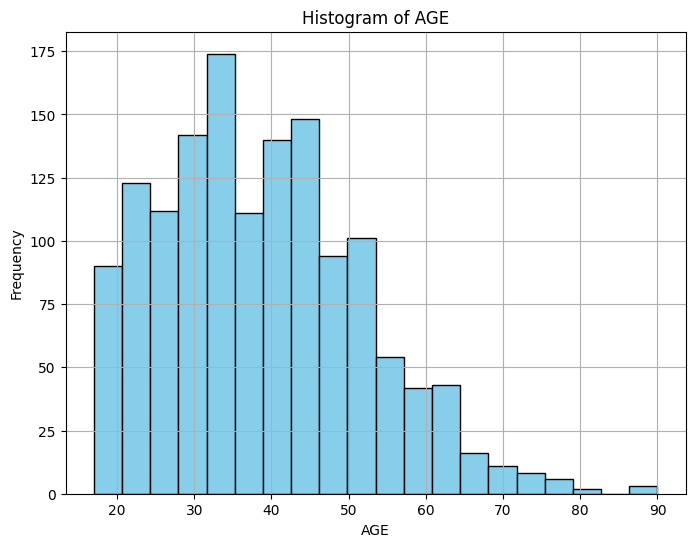

Choose a variable to display its histogram (type 'exit' to quit):
CUST_GENDER, AGE, CUST_MARITAL_STATUS, COUNTRY_NAME, CUST_INCOME_LEVEL, EDUCATION, OCCUPATION, HOUSEHOLD_SIZE, YRS_RESIDENCE, AFFINITY_CARD, HOME_THEATER_PACKAGE, BOOKKEEPING_APPLICATION, PRINTER_SUPPLIES, Y_BOX_GAMES
Enter variable name: OCCUPATION


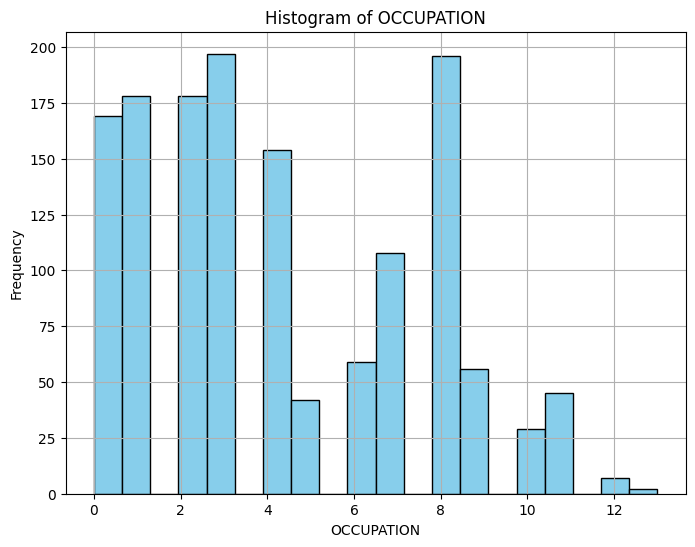

Choose a variable to display its histogram (type 'exit' to quit):
CUST_GENDER, AGE, CUST_MARITAL_STATUS, COUNTRY_NAME, CUST_INCOME_LEVEL, EDUCATION, OCCUPATION, HOUSEHOLD_SIZE, YRS_RESIDENCE, AFFINITY_CARD, HOME_THEATER_PACKAGE, BOOKKEEPING_APPLICATION, PRINTER_SUPPLIES, Y_BOX_GAMES
Enter variable name: exit
Exiting the program...


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Function to display histogram plot for a chosen variable
def display_histogram(variable):
    plt.figure(figsize=(8, 6))
    plt.hist(cleaned_df[variable], bins=20, color='skyblue', edgecolor='black')
    plt.title(f'Histogram of {variable}')
    plt.xlabel(variable)
    plt.ylabel('Frequency')
    plt.grid(True)
    plt.show()

# Main program loop
while True:
    print("Choose a variable to display its histogram (type 'exit' to quit):")
    print(", ".join(cleaned_df.columns))
    choice = input("Enter variable name: ")

    if choice.lower() == 'exit':
        print("Exiting the program...")
        break

    if choice in cleaned_df.columns:
        display_histogram(choice)
    else:
        print("Invalid variable name. Please try again.")

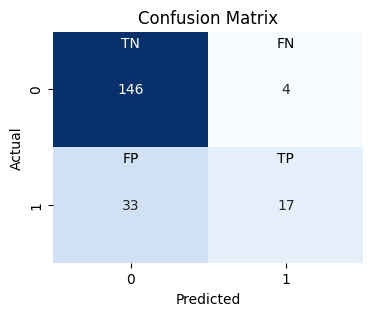

Accuracy: 0.815
Confusion Matrix:
 [[146   4]
 [ 33  17]]


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

# Select 1000 random customer records
random_data = cleaned_df.sample(n=1000, random_state=42)

# Extract features and target variable
features = ['CUST_GENDER', 'AGE', 'CUST_MARITAL_STATUS', 'COUNTRY_NAME', 'CUST_INCOME_LEVEL',
            'EDUCATION', 'OCCUPATION', 'HOUSEHOLD_SIZE', 'YRS_RESIDENCE'
             ]
target = 'AFFINITY_CARD'

X = random_data[features]
y = random_data[target]

# Split Data into Training and Testing Sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Build and Train Logistic Regression Model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Evaluate Model Performance
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

# Import the libraries
from sklearn import metrics
import seaborn as sns
import matplotlib.pyplot as plt

# Calculating the confusion matrix
plt.figure(figsize=(4, 3))
sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt='g', cbar=False)

# Add labels and title
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

# Add labels for TN, FN, TP, FP
plt.text(0.5, 0.1, 'TN', ha='center', va='center', color='white')
plt.text(0.5, 1.1, 'FP', ha='center', va='center')
plt.text(1.5, 0.1, 'FN', ha='center', va='center')
plt.text(1.5, 1.1, 'TP', ha='center', va='center')

# Show plot
plt.show()

print("Accuracy:", accuracy)
print("Confusion Matrix:\n", conf_matrix)

In [ ]:
from sklearn.metrics import classification_report
target_names = ['without Affinity card', 'with Affinity card']
print(classification_report(y_test, y_pred, target_names = target_names))

                       precision    recall  f1-score   support

without Affinity card       0.82      0.97      0.89       150
   with Affinity card       0.81      0.34      0.48        50

             accuracy                           0.81       200
            macro avg       0.81      0.66      0.68       200
         weighted avg       0.81      0.81      0.79       200



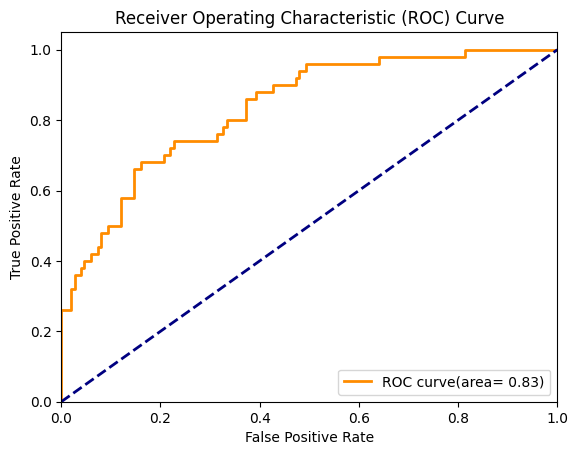

In [ ]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
model.fit(X_train, y_train)
y_prob = model.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr,tpr)
plt.figure()
plt.plot(fpr, tpr, color ='darkorange', lw=2, label='ROC curve(area= %0.2f)' %roc_auc )
plt.plot([0,1], [0,1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

In [ ]:
import joblib
joblib.dump(model, 'logistic_regression_model.pkl')

import pandas as pd
from sklearn.linear_model import LogisticRegression
import joblib  # For model serialization (saving and loading)


# Load the trained logistic regression model
model = joblib.load('logistic_regression_model.pkl')

# Function to accept user input and make predictions
def predict_from_user_input():
    print("Enter customer details to predict affinity card (type 'exit' to quit)")

    while True:
        # Gather user input for customer details
        cust_gender = input("Gender (0 for female, 1 for male): ")
        if cust_gender.lower() == 'exit':
            break

        age = int(input("Age: "))
        marital_status = input("Marital Status: ")
        country_name = input("Country Name: ")
        income_level = input("Income Level: ")
        education = input("Education: ")
        occupation = input("Occupation: ")
        household_size = input("Household Size: ")
        yrs_residence = int(input("Years of Residence: "))

        # Prepare input data for prediction
        input_data = {
            'CUST_GENDER': [int(cust_gender)],
            'AGE': [age],
            'CUST_MARITAL_STATUS': [marital_status],
            'COUNTRY_NAME': [country_name],
            'CUST_INCOME_LEVEL': [income_level],
            'EDUCATION': [education],
            'OCCUPATION': [occupation],
            'HOUSEHOLD_SIZE': [household_size],
            'YRS_RESIDENCE': [yrs_residence]
        }

        # Create DataFrame from user input
        input_df = pd.DataFrame(input_data)

        # Make prediction
        prediction = model.predict(input_df)

        if prediction[0] == 1:
            print("Predicted: Customer will purchase affinity card.")
        else:
            print("Predicted: Customer will not purchase affinity card.")


# Function to accept file input and make batch predictions
def predict_from_file(file_path):

# Make predictions using the filtered prediction data
    features = ['CUST_GENDER', 'AGE', 'CUST_MARITAL_STATUS', 'COUNTRY_NAME', 'CUST_INCOME_LEVEL',
            'EDUCATION', 'OCCUPATION', 'HOUSEHOLD_SIZE', 'YRS_RESIDENCE'
             ]
    data_filtered = random_data[features]
    predictions = model.predict(data_filtered)

    return random_data

# Usage example:
predict_from_user_input()


# Example of batch prediction from a file
predicted_data = predict_from_file(random_data)
print(predicted_data.head())  # Display predicted data

Enter customer details to predict affinity card (type 'exit' to quit)
Gender (0 for female, 1 for male): 0
Age: 41
Marital Status: 0
Country Name: 18
Income Level: 3
Education: 14
Occupation: 0
Household Size: 2
Years of Residence: 4
Predicted: Customer will not purchase affinity card.
Gender (0 for female, 1 for male): exit
     CUST_GENDER  AGE  CUST_MARITAL_STATUS COUNTRY_NAME CUST_INCOME_LEVEL  \
53             1   64                    1           18                 3   
309            1   27                    0            0                 3   
719            1   45                    2           18                 2   
1066           1   23                    0           18                 3   
392            1   27                    0           18                 2   

      EDUCATION  OCCUPATION HOUSEHOLD_SIZE  YRS_RESIDENCE  AFFINITY_CARD  \
53            9           1              3              6              0   
309          10           4              1              3 

In [ ]:
# Remove the selected subset from the original dataset to obtain the remaining data
remaining_data = cleaned_df.drop(random_data.index)

# Save the remaining data to a CSV file
remaining_data.to_csv('remaining_data.csv',index=False)

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler


rest_data = remaining_data.sample(n = 100, random_state = 42)
rest_data.head()


X = rest_data.drop(['AFFINITY_CARD'], axis = 1)
y = rest_data['AFFINITY_CARD']

#Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Create the logistic regression model
model = LogisticRegression()

# Train the model on the training data
model.fit(X_train, y_train)

# Make predictions on the testing data
y_pred = model.predict(X_test)
y_pred

# Evaluate the model's accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:",accuracy)

Accuracy: 0.7666666666666667
